**Task 1 : Speech Recording at 48 kHz and Resampling to 16 kHz**

In [ ]:
pip install librosa soundfile

In [ ]:
audio_path = "English.wav"

In [ ]:
import librosa

In [ ]:
import soundfile as sf

In [ ]:
audio, original_sr = librosa.load(audio_path, sr=None)


print(f"Original Sampling Rate: {original_sr} Hz")

In [ ]:
target_sr = 16000

audio_16k = librosa.resample(
    audio,
    orig_sr=original_sr,
    target_sr=target_sr
)


output_path = "english_16k.wav"

In [ ]:
sf.write(output_path, audio_16k, target_sr)

print(f"Resampled audio saved as: {output_path}")
print(f"New Sampling Rate: {target_sr} Hz")

Original Sampling Rate: 48000 Hz
Resampled audio saved as: english_16k.wav
New Sampling Rate: 16000 Hz


In [ ]:
len(audio)

333677

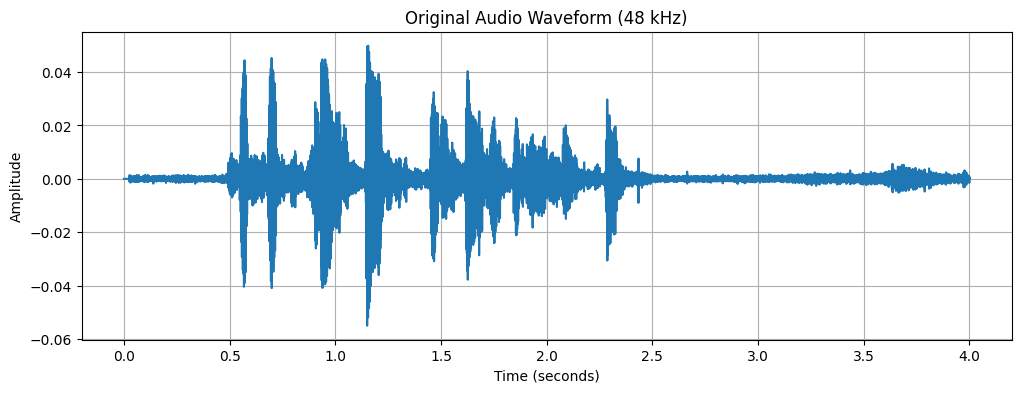

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
DURATION = 4
time_original = np.linspace(0, DURATION, len(audio))

plt.figure(figsize=(12, 4))
plt.plot(time_original, audio)
plt.title("Original Audio Waveform (48 kHz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

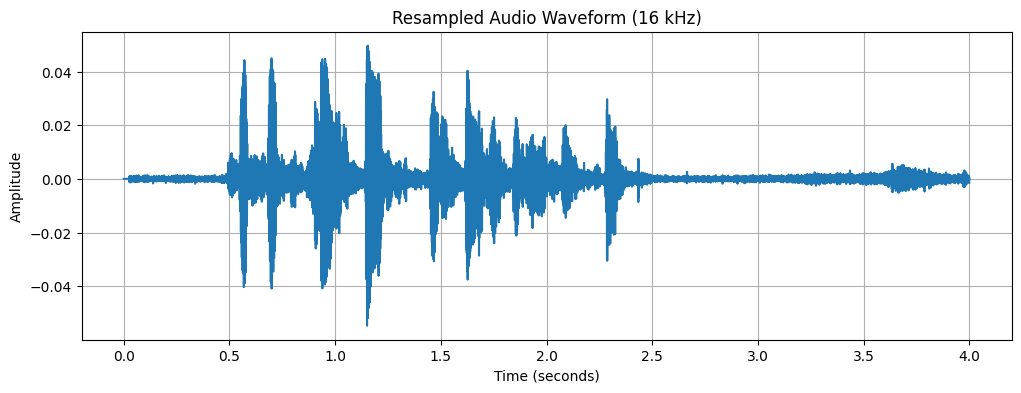

In [ ]:
time_resampled = np.linspace(
    0,
    DURATION,
    len(audio_16k)
)

plt.figure(figsize=(12, 4))
plt.plot(time_resampled, audio_16k)
plt.title("Resampled Audio Waveform (16 kHz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [ ]:
print(f"Original Sampling Rate : {original_sr} Hz")
print(f"Resampled Sampling Rate: {target_sr} Hz")

print(f"\nOriginal Number of Samples : {len(audio)}")
print(f"Resampled Number of Samples: {len(audio_16k)}")

print(f"\nOriginal Duration : {len(audio)/original_sr:.2f} seconds")
print(f"Resampled Duration: {len(audio_16k)/target_sr:.2f} seconds")


--- Audio Information ---
Original Sampling Rate : 48000 Hz
Resampled Sampling Rate: 16000 Hz

Original Number of Samples : 333677
Resampled Number of Samples: 111226

Original Duration : 6.95 seconds
Resampled Duration: 6.95 seconds


**Lab 2 : Extracting MFCC features**

In [ ]:
"""
MFCC Feature Extraction from recording.wav
"""

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np


audio_path = "english_16k.wav"

signal, sr = librosa.load(audio_path, sr=None)

print(f"Sampling Rate: {sr} Hz")
print(f"Audio Duration: {len(signal)/sr:.2f} seconds")

In [ ]:
n_mfcc = 13

mfccs = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=n_mfcc
)


print(f"MFCC Shape: {mfccs.shape}")

# Rows  - MFCC coefficients
# Columns - Time frames

Sampling Rate: 16000 Hz
Audio Duration: 6.95 seconds
MFCC Shape: (13, 218)


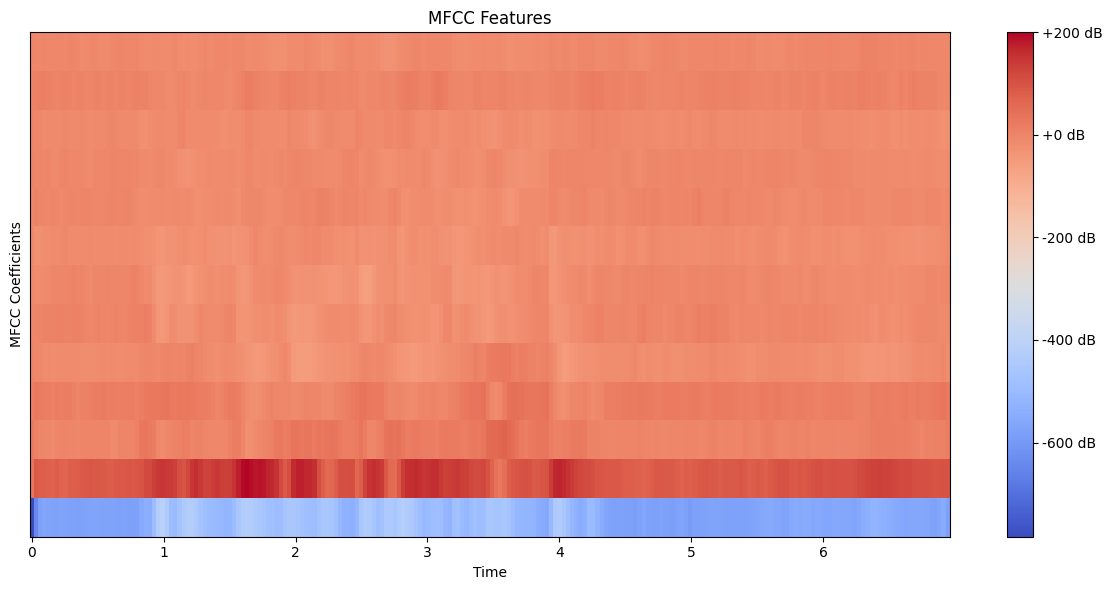


First 5 Frames of MFCC Features:

[[-437.68045   -424.7605    -428.80194   -442.546     -455.82553  ]
 [ 193.0952     200.00626    190.66325    182.06581    186.11539  ]
 [   0.9935074  -19.193867   -19.974287    -9.12644     -3.9851909]
 [   1.4097182  -13.836895   -20.287582   -21.696762   -18.447521 ]
 [ -25.495146   -31.694191   -38.19773    -42.23324    -44.084625 ]
 [ -32.122635   -31.168514   -28.99416    -22.044828   -19.256098 ]
 [ -38.51541    -36.45682    -24.768656   -13.58688    -11.568382 ]
 [ -30.456316   -24.3306     -14.009676    -7.350373   -12.76629  ]
 [  -9.601865    -3.6914744   -7.306995    -6.7645326   -4.1827173]
 [ -12.658745    -6.3003225   -6.5032988  -13.968166   -12.767291 ]
 [ -12.1946125   -1.1127565   -3.1354363  -10.363989    -9.359264 ]
 [   9.760009    16.301537    16.403854    11.331619     5.9293175]
 [  -4.928807   -13.69965    -14.714607    -8.720715   -10.477354 ]]


In [ ]:
plt.figure(figsize=(12, 6))

librosa.display.specshow(
    mfccs,
    x_axis='time',
    sr=sr
)

plt.colorbar(format='%+2.0f dB')

plt.title("MFCC Features")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")

plt.tight_layout()
plt.show()




In [ ]:
print("\nFirst 5 Frames of MFCC Features:\n")
print(mfccs[:, 50:55])